In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

# Project root
BASE_DIR = Path.cwd().parent

# Raw data folder
DATA_DIR = BASE_DIR / "data" / "raw"

# File paths
dataset_path = DATA_DIR / "dataset.csv"
severity_path = DATA_DIR / "Symptom-severity.csv"
description_path = DATA_DIR / "symptom_Description.csv"
precaution_path = DATA_DIR / "symptom_precaution.csv"

# Load datasets
df = pd.read_csv(dataset_path)
severity_df = pd.read_csv(severity_path)
description_df = pd.read_csv(description_path)
precaution_df = pd.read_csv(precaution_path)

print("Main dataset:", df.shape)
print("Severity dataset:", severity_df.shape)
print("Description dataset:", description_df.shape)
print("Precaution dataset:", precaution_df.shape)

Main dataset: (4920, 18)
Severity dataset: (133, 2)
Description dataset: (41, 2)
Precaution dataset: (41, 5)


In [5]:
df.columns = df.columns.str.strip()

severity_df.columns = severity_df.columns.str.strip()
description_df.columns = description_df.columns.str.strip()
precaution_df.columns = precaution_df.columns.str.strip()

print(df.columns.tolist())

['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']


In [6]:
df["Disease"] = (
    df["Disease"]
    .astype(str)
    .str.strip()
)

print("Number of diseases:", df["Disease"].nunique())

print("\nDisease names:")
print(sorted(df["Disease"].unique()))

Number of diseases: 41

Disease names:
['(vertigo) Paroymsal  Positional Vertigo', 'AIDS', 'Acne', 'Alcoholic hepatitis', 'Allergy', 'Arthritis', 'Bronchial Asthma', 'Cervical spondylosis', 'Chicken pox', 'Chronic cholestasis', 'Common Cold', 'Dengue', 'Diabetes', 'Dimorphic hemmorhoids(piles)', 'Drug Reaction', 'Fungal infection', 'GERD', 'Gastroenteritis', 'Heart attack', 'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E', 'Hypertension', 'Hyperthyroidism', 'Hypoglycemia', 'Hypothyroidism', 'Impetigo', 'Jaundice', 'Malaria', 'Migraine', 'Osteoarthristis', 'Paralysis (brain hemorrhage)', 'Peptic ulcer diseae', 'Pneumonia', 'Psoriasis', 'Tuberculosis', 'Typhoid', 'Urinary tract infection', 'Varicose veins', 'hepatitis A']


In [7]:
symptom_columns = [col for col in df.columns if col.startswith("Symptom_")]

for col in symptom_columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace(" ", "_")
    )

print(df[symptom_columns].head())

   Symptom_1             Symptom_2             Symptom_3            Symptom_4  \
0    itching             skin_rash  nodal_skin_eruptions  dischromic__patches   
1  skin_rash  nodal_skin_eruptions   dischromic__patches                 <NA>   
2    itching  nodal_skin_eruptions   dischromic__patches                 <NA>   
3    itching             skin_rash   dischromic__patches                 <NA>   
4    itching             skin_rash  nodal_skin_eruptions                 <NA>   

  Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9 Symptom_10 Symptom_11  \
0      <NA>      <NA>      <NA>      <NA>      <NA>       <NA>       <NA>   
1      <NA>      <NA>      <NA>      <NA>      <NA>       <NA>       <NA>   
2      <NA>      <NA>      <NA>      <NA>      <NA>       <NA>       <NA>   
3      <NA>      <NA>      <NA>      <NA>      <NA>       <NA>       <NA>   
4      <NA>      <NA>      <NA>      <NA>      <NA>       <NA>       <NA>   

  Symptom_12 Symptom_13 Symptom_14 Symptom_15 Symp

In [8]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 4616


In [9]:
# Clean column names

df.columns = df.columns.str.strip()
severity_df.columns = severity_df.columns.str.strip()
description_df.columns = description_df.columns.str.strip()
precaution_df.columns = precaution_df.columns.str.strip()

print("Main dataset columns:")
print(df.columns.tolist())

print("\nSeverity dataset columns:")
print(severity_df.columns.tolist())

print("\nDescription dataset columns:")
print(description_df.columns.tolist())

print("\nPrecaution dataset columns:")
print(precaution_df.columns.tolist())

Main dataset columns:
['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']

Severity dataset columns:
['Symptom', 'weight']

Description dataset columns:
['Disease', 'Description']

Precaution dataset columns:
['Disease', 'Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']


In [10]:
# Clean disease names

df["Disease"] = (
    df["Disease"]
    .astype(str)
    .str.strip()
)

# Identify symptom columns
symptom_columns = [
    col for col in df.columns
    if col.startswith("Symptom_")
]

# Clean symptom values
for col in symptom_columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace(" ", "_")
    )

# Clean severity dataset
severity_df["Symptom"] = (
    severity_df["Symptom"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(" ", "_")
)

print("Symptom columns:", len(symptom_columns))
print("\nFirst 5 cleaned records:")
display(df.head())

Symptom columns: 17

First 5 cleaned records:


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic__patches,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic__patches,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,Fungal infection,itching,nodal_skin_eruptions,dischromic__patches,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,Fungal infection,itching,skin_rash,dischromic__patches,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [11]:
print("Total records:", len(df))
print("Unique diseases:", df["Disease"].nunique())

print("\nDisease distribution:")
print(df["Disease"].value_counts())

Total records: 4920
Unique diseases: 41

Disease distribution:
Disease
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                         

In [12]:
duplicate_count=df.duplicated().sum()
print("Duplicate rows:",duplicate_count)

Duplicate rows: 4616


In [13]:
# Build complete symptom vocabulary

all_symptoms = set()

for col in symptom_columns:
    symptoms = df[col].dropna().unique()
    all_symptoms.update(symptoms)

all_symptoms = sorted(all_symptoms)

print("Total unique symptoms:", len(all_symptoms))

print("\nFirst 30 symptoms:")
print(all_symptoms[:30])

Total unique symptoms: 131

First 30 symptoms:
['abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium', 'anxiety', 'back_pain', 'belly_pain', 'blackheads', 'bladder_discomfort', 'blister', 'blood_in_sputum', 'bloody_stool', 'blurred_and_distorted_vision', 'breathlessness', 'brittle_nails', 'bruising', 'burning_micturition', 'chest_pain', 'chills', 'cold_hands_and_feets', 'coma', 'congestion', 'constipation', 'continuous_feel_of_urine', 'continuous_sneezing', 'cough', 'cramps', 'dark_urine', 'dehydration']


In [14]:
# Compare symptoms between datasets

severity_symptoms = set(severity_df["Symptom"].dropna())

dataset_symptoms = set(all_symptoms)

missing_severity = dataset_symptoms - severity_symptoms
unused_severity = severity_symptoms - dataset_symptoms

print("Symptoms in main dataset:", len(dataset_symptoms))
print("Symptoms in severity dataset:", len(severity_symptoms))

print("\nSymptoms missing from severity dataset:", len(missing_severity))
print("Symptoms in severity dataset but not main dataset:", len(unused_severity))

if missing_severity:
    print("\nMissing severity symptoms:")
    print(sorted(missing_severity))

Symptoms in main dataset: 131
Symptoms in severity dataset: 132

Symptoms missing from severity dataset: 3
Symptoms in severity dataset but not main dataset: 4

Missing severity symptoms:
['dischromic__patches', 'foul_smell_of_urine', 'spotting__urination']


In [15]:
# Normalize symptom names in both datasets

def normalize_symptom(value):
    if pd.isna(value):
        return value
    
    value = str(value).strip().lower()
    value = value.replace(" ", "_")
    
    # Replace multiple underscores with one
    value = "_".join(part for part in value.split("_") if part)
    
    return value


# Normalize main dataset symptoms
for col in symptom_columns:
    df[col] = df[col].apply(normalize_symptom)


# Normalize severity dataset
severity_df["Symptom"] = severity_df["Symptom"].apply(normalize_symptom)


# Rebuild symptom vocabulary
all_symptoms = set()

for col in symptom_columns:
    all_symptoms.update(df[col].dropna().unique())

all_symptoms = sorted(all_symptoms)

severity_symptoms = set(
    severity_df["Symptom"].dropna()
)

missing_severity = set(all_symptoms) - severity_symptoms
unused_severity = severity_symptoms - set(all_symptoms)

print("Main dataset symptoms:", len(all_symptoms))
print("Severity dataset symptoms:", len(severity_symptoms))

print("\nMissing severity symptoms:", len(missing_severity))
print(sorted(missing_severity))

print("\nUnused severity symptoms:", len(unused_severity))
print(sorted(unused_severity))

Main dataset symptoms: 131
Severity dataset symptoms: 132

Missing severity symptoms: 1
['foul_smell_of_urine']

Unused severity symptoms: 2
['foul_smell_ofurine', 'prognosis']


In [16]:
print(
    "\nDuplicate symptom entries in severity dataset:",
    severity_df["Symptom"].duplicated().sum()
)


Duplicate symptom entries in severity dataset: 1


In [17]:
# Create multi-hot encoded dataset

# Start with disease column
processed_df = pd.DataFrame()
processed_df["Disease"] = df["Disease"]

# Create one binary column for every symptom
for symptom in all_symptoms:
    processed_df[symptom] = 0

# Mark symptoms present in each record
for index, row in df.iterrows():
    for col in symptom_columns:
        symptom = row[col]

        if pd.notna(symptom) and symptom in all_symptoms:
            processed_df.loc[index, symptom] = 1

print("Processed dataset shape:", processed_df.shape)

print("\nFirst 5 rows:")
display(processed_df.head())

C:\Users\hp\AppData\Local\Temp\ipykernel_17872\4124976100.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  processed_df[symptom] = 0


Processed dataset shape: (4920, 132)

First 5 rows:


,Disease,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,...,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
0,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Fungal infection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:

print("Number of rows:", len(processed_df))
print("Number of symptom features:", len(processed_df.columns) - 1)

print("\nDisease column:")
print(processed_df["Disease"].head())

print("\nFeature values:")
print(processed_df.iloc[:5, :10])

Number of rows: 4920
Number of symptom features: 131

Disease column:
0    Fungal infection
1    Fungal infection
2    Fungal infection
3    Fungal infection
4    Fungal infection
Name: Disease, dtype: str

Feature values:
            Disease  abdominal_pain  abnormal_menstruation  acidity  \
0  Fungal infection               0                      0        0   
1  Fungal infection               0                      0        0   
2  Fungal infection               0                      0        0   
3  Fungal infection               0                      0        0   
4  Fungal infection               0                      0        0   

   acute_liver_failure  altered_sensorium  anxiety  back_pain  belly_pain  \
0                    0                  0        0          0           0   
1                    0                  0        0          0           0   
2                    0                  0        0          0           0   
3                    0                  0 

In [19]:
# Check whether any unexpected values exist

feature_columns = [
    col for col in processed_df.columns
    if col != "Disease"
]

unique_values = set(
    processed_df[feature_columns].values.flatten()
)

print("Unique feature values:", unique_values)

Unique feature values: {np.int64(0), np.int64(1)}


In [20]:
processed_dir = BASE_DIR / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

In [21]:
processed_path = processed_dir / "disease_symptom_processed.csv"

processed_df.to_csv(processed_path, index=False)

print("Saved successfully:")
print(processed_path)

Saved successfully:
c:\Users\hp\OneDrive\Desktop\smart_hospital_assistant\data\processed\disease_symptom_processed.csv


In [22]:
print("Processed dataset shape:", processed_df.shape)

feature_columns = [col for col in processed_df.columns if col != "Disease"]

unique_values = set(processed_df[feature_columns].values.flatten())

print("Number of symptom features:", len(feature_columns))
print("Unique feature values:", unique_values)

Processed dataset shape: (4920, 132)
Number of symptom features: 131
Unique feature values: {np.int64(0), np.int64(1)}


In [23]:
processed_path = BASE_DIR / "data" / "processed" / "disease_symptom_processed.csv"

print("File exists:", processed_path.exists())
print("File path:", processed_path)

File exists: True
File path: c:\Users\hp\OneDrive\Desktop\smart_hospital_assistant\data\processed\disease_symptom_processed.csv


In [24]:
# Clean disease names in supporting datasets

description_df["Disease"] = (
    description_df["Disease"]
    .astype(str)
    .str.strip()
)

precaution_df["Disease"] = (
    precaution_df["Disease"]
    .astype(str)
    .str.strip()
)

# Clean description text
description_df["Description"] = (
    description_df["Description"]
    .astype(str)
    .str.strip()
)

# Clean precaution columns
precaution_columns = [
    col for col in precaution_df.columns
    if col.startswith("Precaution_")
]

for col in precaution_columns:
    precaution_df[col] = (
        precaution_df[col]
        .astype("string")
        .str.strip()
    )

print("Descriptions:", description_df.shape)
print("Precautions:", precaution_df.shape)

Descriptions: (41, 2)
Precautions: (41, 5)


In [25]:
# Compare diseases across datasets

main_diseases = set(processed_df["Disease"].unique())
description_diseases = set(description_df["Disease"].unique())
precaution_diseases = set(precaution_df["Disease"].unique())

print("Diseases in processed dataset:", len(main_diseases))
print("Diseases with descriptions:", len(description_diseases))
print("Diseases with precautions:", len(precaution_diseases))

print("\nDiseases without descriptions:")
print(sorted(main_diseases - description_diseases))

print("\nDiseases without precautions:")
print(sorted(main_diseases - precaution_diseases))

Diseases in processed dataset: 41
Diseases with descriptions: 41
Diseases with precautions: 41

Diseases without descriptions:
['Dimorphic hemmorhoids(piles)']

Diseases without precautions:
[]


In [26]:
# Merge disease descriptions

disease_knowledge_df = description_df.merge(
    precaution_df,
    on="Disease",
    how="outer"
)

print("Disease knowledge dataset shape:", disease_knowledge_df.shape)

display(disease_knowledge_df.head())

Disease knowledge dataset shape: (42, 6)


,Disease,Description,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,(vertigo) Paroymsal Positional Vertigo,Benign paroxysmal positional vertigo (BPPV) is...,lie down,avoid sudden change in body,avoid abrupt head movment,relax
1,AIDS,Acquired immunodeficiency syndrome (AIDS) is a...,avoid open cuts,wear ppe if possible,consult doctor,follow up
2,Acne,"Acne vulgaris is the formation of comedones, p...",bath twice,avoid fatty spicy food,drink plenty of water,avoid too many products
3,Alcoholic hepatitis,"Alcoholic hepatitis is a diseased, inflammator...",stop alcohol consumption,consult doctor,medication,follow up
4,Allergy,An allergy is an immune system response to a f...,apply calamine,cover area with bandage,<NA>,use ice to compress itching


In [27]:
def combine_precautions(row):
    precautions = []

    for col in precaution_columns:
        value = row[col]

        if pd.notna(value) and str(value).strip():
            precautions.append(str(value).strip())

    return "; ".join(precautions)


disease_knowledge_df["Precautions"] = (
    disease_knowledge_df.apply(combine_precautions, axis=1)
)

print(disease_knowledge_df[
    ["Disease", "Description", "Precautions"]
].head())

                                   Disease  \
0  (vertigo) Paroymsal  Positional Vertigo   
1                                     AIDS   
2                                     Acne   
3                      Alcoholic hepatitis   
4                                  Allergy   

                                         Description  \
0  Benign paroxysmal positional vertigo (BPPV) is...   
1  Acquired immunodeficiency syndrome (AIDS) is a...   
2  Acne vulgaris is the formation of comedones, p...   
3  Alcoholic hepatitis is a diseased, inflammator...   
4  An allergy is an immune system response to a f...   

                                         Precautions  
0  lie down; avoid sudden change in body; avoid a...  
1  avoid open cuts; wear ppe if possible; consult...  
2  bath twice; avoid fatty spicy food; drink plen...  
3  stop alcohol consumption; consult doctor; medi...  
4  apply calamine; cover area with bandage; use i...  


In [28]:
knowledge_path = (
    BASE_DIR
    / "data"
    / "processed"
    / "disease_knowledge.csv"
)

disease_knowledge_df.to_csv(
    knowledge_path,
    index=False
)

print("Disease knowledge dataset saved:")
print(knowledge_path)

Disease knowledge dataset saved:
c:\Users\hp\OneDrive\Desktop\smart_hospital_assistant\data\processed\disease_knowledge.csv


In [29]:
from sklearn.model_selection import train_test_split

# Features and target
X = processed_df.drop("Disease", axis=1)
y = processed_df["Disease"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", y.nunique())

X shape: (4920, 131)
y shape: (4920,)
Number of classes: 41


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class count:", y_train.nunique())
print("Testing class count:", y_test.nunique())

Training samples: 3936
Testing samples: 984

Training class count: 41
Testing class count: 41


In [31]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [32]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_lr = logistic_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 1.0

Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00

In [33]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [34]:
y_pred_rf = random_forest_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      

In [35]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf
    ]
})

model_comparison = model_comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(model_comparison)

,Model,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0


<Figure size 1600x1600 with 0 Axes>

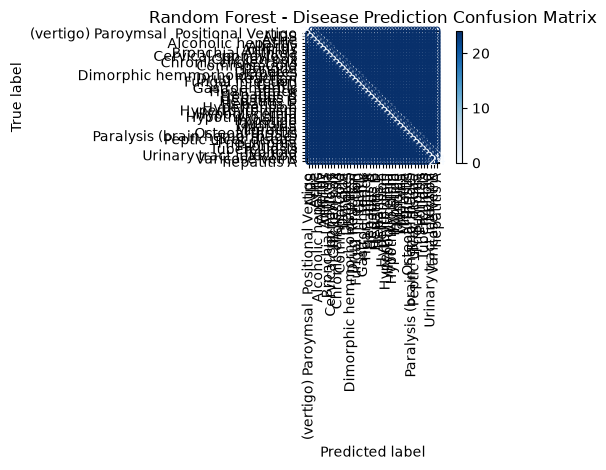

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(16, 16))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    xticks_rotation="vertical",
    cmap="Blues"
)

plt.title("Random Forest - Disease Prediction Confusion Matrix")
plt.tight_layout()
plt.show()

In [37]:
import joblib

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

disease_model_path = MODEL_DIR / "disease_prediction_model.pkl"

joblib.dump(
    random_forest_model,
    disease_model_path
)

print("Disease prediction model saved:")
print(disease_model_path)

Disease prediction model saved:
c:\Users\hp\OneDrive\Desktop\smart_hospital_assistant\models\disease_prediction_model.pkl


In [38]:
feature_columns_path = MODEL_DIR / "disease_prediction_features.pkl"

joblib.dump(
    list(X.columns),
    feature_columns_path
)

print("Feature list saved:")
print(feature_columns_path)

Feature list saved:
c:\Users\hp\OneDrive\Desktop\smart_hospital_assistant\models\disease_prediction_features.pkl


In [39]:
feature_columns_path = MODEL_DIR / "disease_prediction_features.pkl"

joblib.dump(
    list(X.columns),
    feature_columns_path
)

print("Feature list saved:")
print(feature_columns_path)

Feature list saved:
c:\Users\hp\OneDrive\Desktop\smart_hospital_assistant\models\disease_prediction_features.pkl
